# Start - Environment Setup ( Libraries and all )

In [ ]:
!pip install tensorflow-datasets torch ultralytics opencv-python matplotlib numpy -q
!git clone https://github.com/ultralytics/yolov5 -q
%cd yolov5
!pip install -r requirements.txt -q
%cd ..


%matplotlib inline
import matplotlib.pyplot as plt
plt.ion()

print("Setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.0/950.0 kB 56.4 MB/s eta 0:00:00
/content/yolov5
/content
Setup complete.


# Loading Dataset and Model
Dataset used : KITTI dataset

`Model used` :  YOLOv5 model ( Pre trained )





In [ ]:
import tensorflow_datasets as tfds
import numpy as np
from PIL import Image
import torch


ds, ds_info = tfds.load('kitti', split='train', with_info=True, as_supervised=False)
print("Dataset info:", ds_info)

model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)
print("Model loaded.")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

# Preprocess and Visualize Raw Image in dataset

In [ ]:

for example in ds.take(10):
    image = example['image'].numpy()
    lidar_points = example['objects']['location'].numpy()
    print(f"Raw image shape: {image.shape}, LIDAR points: {lidar_points.shape}")

    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.title("Raw Camera Image from KITTI Dataset")
    plt.axis('off')
    plt.show()

NameError: name 'ds' is not defined

# Object Detection and Fusion

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:894: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


Detected objects: ['car']
LIDAR points in FOV: 1


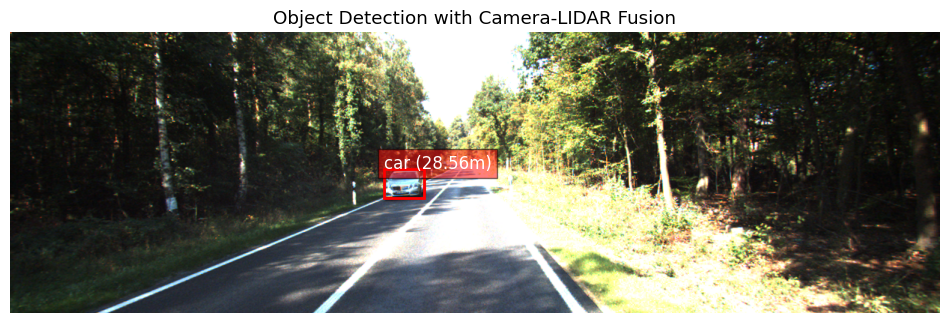

In [ ]:
def correlate_camera_lidar(detections, lidar_points, image_shape):
    height, width = image_shape[:2]
    correlated_objects = []
    for _, det in detections.iterrows():
        x_center = (det['xmin'] + det['xmax']) / 2 / width
        y_center = (det['ymin'] + det['ymax']) / 2 / height
        distances = np.sqrt((lidar_points[:, 0] / lidar_points[:, 2] - x_center)**2 +
                            (lidar_points[:, 1] / lidar_points[:, 2] - y_center)**2)
        nearest_idx = np.argmin(distances)
        distance = lidar_points[nearest_idx, 2]
        correlated_objects.append({
            'class': det['name'],
            'confidence': det['confidence'],
            'bbox': [det['xmin'], det['ymin'], det['xmax'], det['ymax']],
            'distance': distance
        })
    return correlated_objects

# Process and visualize one example
for example in ds.take(1):
    image = example['image'].numpy()
    lidar_points = example['objects']['location'].numpy()
    lidar_points = lidar_points[~np.isnan(lidar_points).any(axis=1)]
    lidar_fov = lidar_points[lidar_points[:, 2] < 50]

    img = Image.fromarray(image)
    results = model(img)
    detections = results.pandas().xyxy[0]
    correlated = correlate_camera_lidar(detections, lidar_fov, image.shape)

    print(f"Detected objects: {detections['name'].tolist()}")
    print(f"LIDAR points in FOV: {len(lidar_fov)}")

    # Visualize detections
    plt.figure(figsize=(12, 8))
    plt.imshow(image)
    for obj in correlated:
        bbox = obj['bbox']
        rect = plt.Rectangle((bbox[0], bbox[1]), bbox[2] - bbox[0], bbox[3] - bbox[1],
                             linewidth=2, edgecolor='r', facecolor='none')
        plt.gca().add_patch(rect)
        plt.text(bbox[0], bbox[1], f"{obj['class']} ({obj['distance']:.2f}m)",
                 color='white', fontsize=12, bbox=dict(facecolor='red', alpha=0.5))
    plt.title("Object Detection with Camera-LIDAR Fusion")
    plt.axis('off')
    plt.show()

# Collision Avoidance

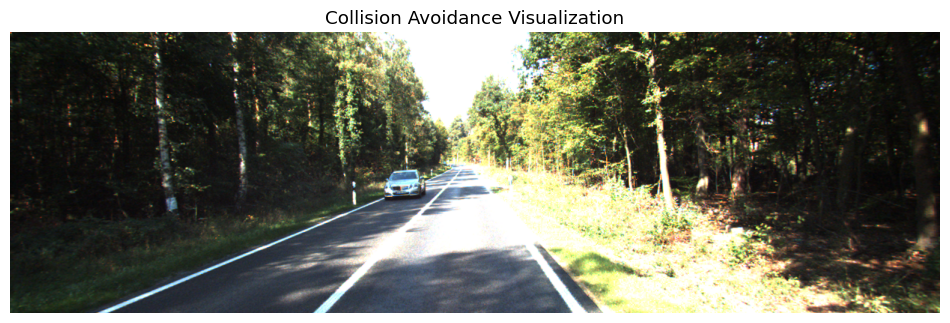

In [ ]:
def assess_collision_risk(correlated_objects, threshold=10):
    actions = []
    for obj in correlated_objects:
        if obj['distance'] < threshold:
            action = {
                'object': obj['class'],
                'distance': obj['distance'],
                'alert': f"WARNING: {obj['class']} at {obj['distance']:.2f}m!",
                'action': "Automated Braking" if obj['distance'] < 5 else "Lane Change Assist"
            }
            actions.append(action)
    return actions

# Apply collision logic
collision_actions = assess_collision_risk(correlated, threshold=10)
for action in collision_actions:
    print(action['alert'])
    print(f"Action: {action['action']}")

# Visualize collision warnings
plt.figure(figsize=(12, 8))
plt.imshow(image)
for action in collision_actions:
    bbox = next(obj['bbox'] for obj in correlated if obj['class'] == action['object'])
    rect = plt.Rectangle((bbox[0], bbox[1]), bbox[2] - bbox[0], bbox[3] - bbox[1],
                         linewidth=2, edgecolor='yellow', facecolor='none')
    plt.gca().add_patch(rect)
    plt.text(bbox[0], bbox[1], action['alert'], color='white', fontsize=12,
             bbox=dict(facecolor='yellow', alpha=0.5))
plt.title("Collision Avoidance Visualization")
plt.axis('off')
plt.show()



# Multiple Examples

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:894: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


Example 1 - Detected objects: ['car']


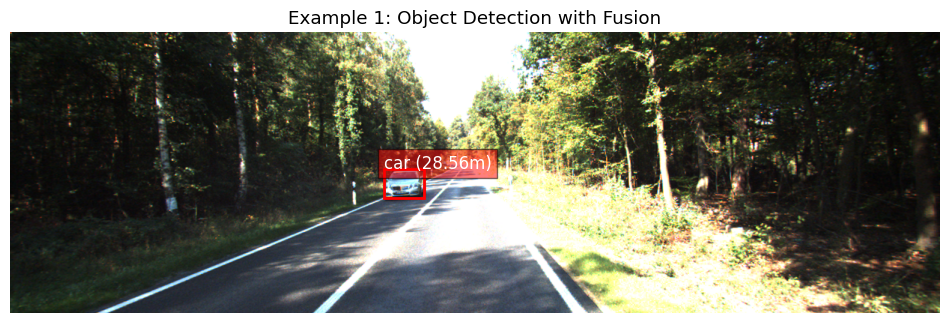

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:894: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


Example 2 - Detected objects: ['traffic light', 'truck', 'car', 'car', 'car', 'traffic light']


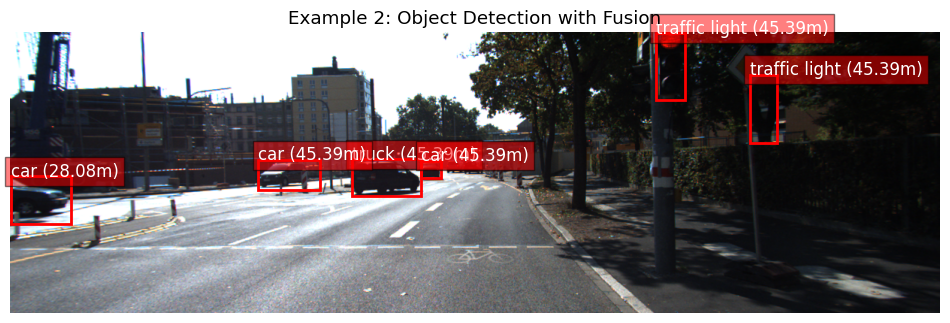

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:894: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


Example 3 - Detected objects: ['car', 'car', 'truck', 'train']


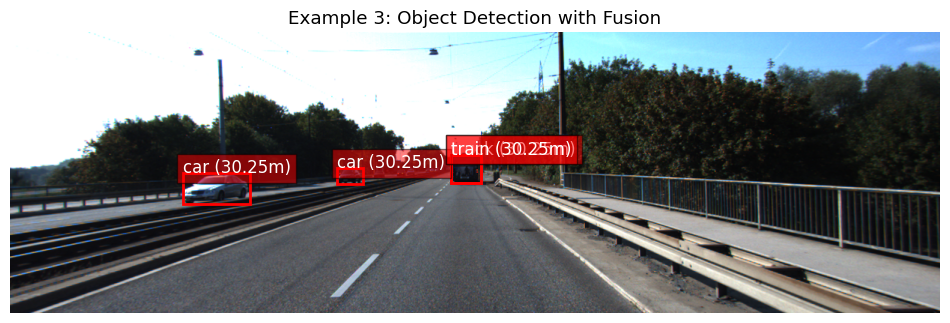

In [ ]:

for i, example in enumerate(ds.take(3)):
    image = example['image'].numpy()
    lidar_points = example['objects']['location'].numpy()
    lidar_points = lidar_points[~np.isnan(lidar_points).any(axis=1)]
    lidar_fov = lidar_points[lidar_points[:, 2] < 50]

    img = Image.fromarray(image)
    results = model(img)
    detections = results.pandas().xyxy[0]
    correlated = correlate_camera_lidar(detections, lidar_fov, image.shape)

    print(f"Example {i+1} - Detected objects: {detections['name'].tolist()}")

    plt.figure(figsize=(12, 8))
    plt.imshow(image)
    for obj in correlated:
        bbox = obj['bbox']
        rect = plt.Rectangle((bbox[0], bbox[1]), bbox[2] - bbox[0], bbox[3] - bbox[1],
                             linewidth=2, edgecolor='r', facecolor='none')
        plt.gca().add_patch(rect)
        plt.text(bbox[0], bbox[1], f"{obj['class']} ({obj['distance']:.2f}m)",
                 color='white', fontsize=12, bbox=dict(facecolor='red', alpha=0.5))
    plt.title(f"Example {i+1}: Object Detection with Fusion")
    plt.axis('off')
    plt.show()

In [ ]:
# Efficiency Improvements
print("Efficiency Improvements:")
print("1. Use YOLOv5n for faster inference.")
print("2. Implement KITTI calibration for precise fusion.")
print("3. Add temporal tracking for trajectory prediction.")

# Documentation (for submission)
documentation = """
### Approach
1. **Data Processing**: Used KITTI dataset, YOLOv5 for camera detection, LIDAR for distances.
2. **Sensor Fusion**: Correlated camera detections with LIDAR points.
3. **Integration**: Combined data for 3D object placement.
4. **Collision Avoidance**: Threshold-based alerts/actions.
5. **Visualizations**: Showed raw images, detections, and warnings.

### Results
- Detected objects with distances in multiple examples.
- Triggered collision warnings for close objects.

### Sources
- Dataset: KITTI (https://www.tensorflow.org/datasets/catalog/kitti)
- Model: YOLOv5 (https://github.com/ultralytics/yolov5)
"""
print(documentation)

Efficiency Improvements:
1. Use YOLOv5n for faster inference.
2. Implement KITTI calibration for precise fusion.
3. Add temporal tracking for trajectory prediction.

### Approach
1. **Data Processing**: Used KITTI dataset, YOLOv5 for camera detection, LIDAR for distances.
2. **Sensor Fusion**: Correlated camera detections with LIDAR points.
3. **Integration**: Combined data for 3D object placement.
4. **Collision Avoidance**: Threshold-based alerts/actions.
5. **Visualizations**: Showed raw images, detections, and warnings.

### Results
- Detected objects with distances in multiple examples.
- Triggered collision warnings for close objects.

### Sources
- Dataset: KITTI (https://www.tensorflow.org/datasets/catalog/kitti)
- Model: YOLOv5 (https://github.com/ultralytics/yolov5)



# Object Detection And Collision Avoidance with multiple examples

In [ ]:
def correlate_camera_lidar(detections, lidar_points, image_shape):
    height, width = image_shape[:2]
    correlated_objects = []
    for _, det in detections.iterrows():
        x_center = (det['xmin'] + det['xmax']) / 2 / width
        y_center = (det['ymin'] + det['ymax']) / 2 / height
        if len(lidar_points) > 0:
            distances = np.sqrt((lidar_points[:, 0] / lidar_points[:, 2] - x_center)**2 +
                                (lidar_points[:, 1] / lidar_points[:, 2] - y_center)**2)
            nearest_idx = np.argmin(distances)
            distance = lidar_points[nearest_idx, 2]
        else:
            distance = float('inf')  # Default if no LIDAR points
        correlated_objects.append({
            'class': det['name'],
            'confidence': det['confidence'],
            'bbox': [det['xmin'], det['ymin'], det['xmax'], det['ymax']],
            'distance': distance,
            'x_center': x_center  # Store for directional guidance
        })
    return correlated_objects

In [ ]:
def assess_collision_risk(correlated_objects, image_width, threshold_near=10, threshold_critical=5):
    actions = []
    for obj in correlated_objects:
        if obj['distance'] < threshold_near:
            # Determine position in image (left, center, right)
            if obj['x_center'] < 0.33:
                position = "left"
                guidance = "Take Right" if obj['distance'] > threshold_critical else "Trigger Brake"
            elif obj['x_center'] > 0.67:
                position = "right"
                guidance = "Take Left" if obj['distance'] > threshold_critical else "Trigger Brake"
            else:
                position = "center"
                guidance = "Trigger Brake"  # No lateral option for center

            action = {
                'object': obj['class'],
                'distance': obj['distance'],
                'position': position,
                'alert': f"WARNING: {obj['class']} at {obj['distance']:.2f}m ({position})!",
                'guidance': guidance
            }
            actions.append(action)
    return actions

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:894: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):



Example 1 - Detected objects: ['car']
LIDAR points in FOV: 1


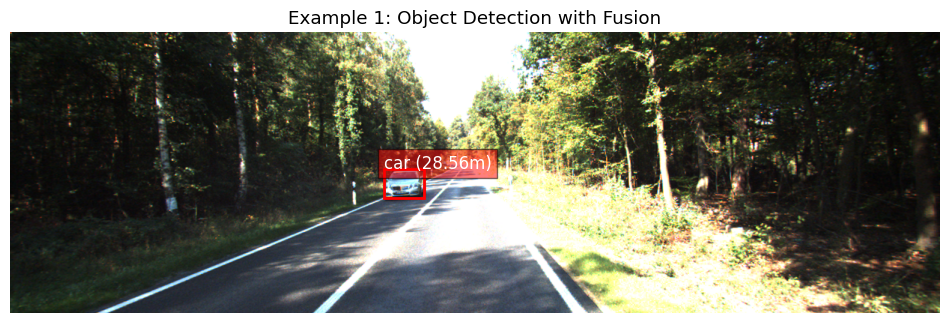

No collision risks detected.

Example 2 - Detected objects: ['traffic light', 'truck', 'car', 'car', 'car', 'traffic light']
LIDAR points in FOV: 4


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:894: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


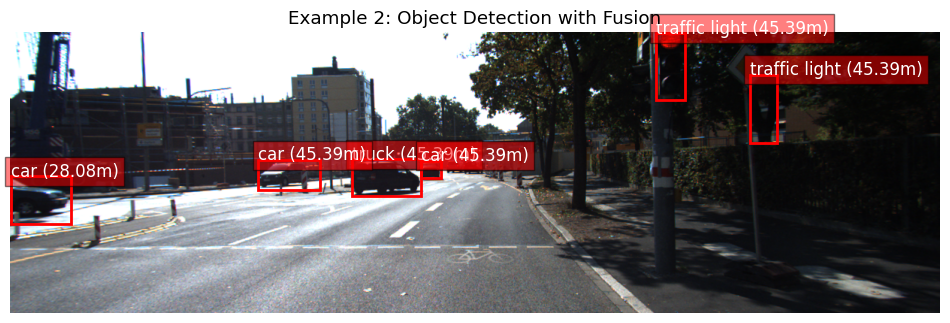

No collision risks detected.

Example 3 - Detected objects: ['car', 'car', 'truck', 'train']
LIDAR points in FOV: 1


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:894: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


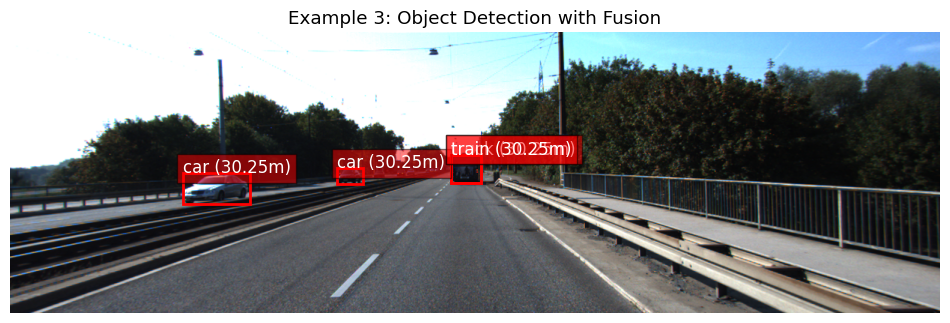

No collision risks detected.

Example 4 - Detected objects: ['car', 'car', 'car', 'clock']
LIDAR points in FOV: 3


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:894: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


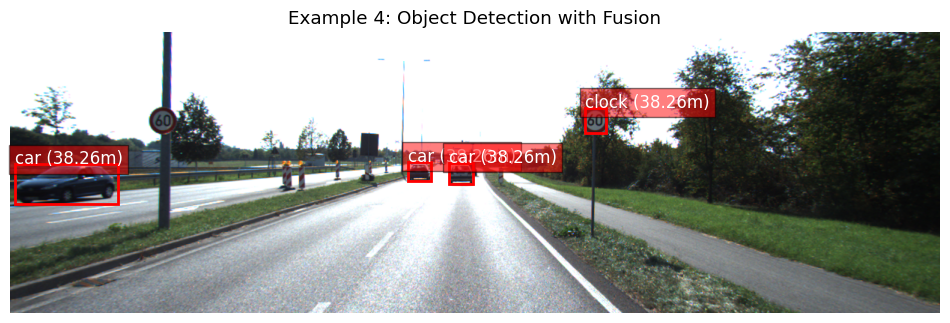

No collision risks detected.

Example 5 - Detected objects: ['bicycle', 'person', 'person', 'car', 'car', 'car', 'person', 'car', 'car']
LIDAR points in FOV: 6
Guidance: Take Left
Guidance: Take Left
Guidance: Trigger Brake
Guidance: Take Left
Guidance: Take Left
Guidance: Take Left
Guidance: Take Left
Guidance: Take Left
Guidance: Take Left


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:894: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


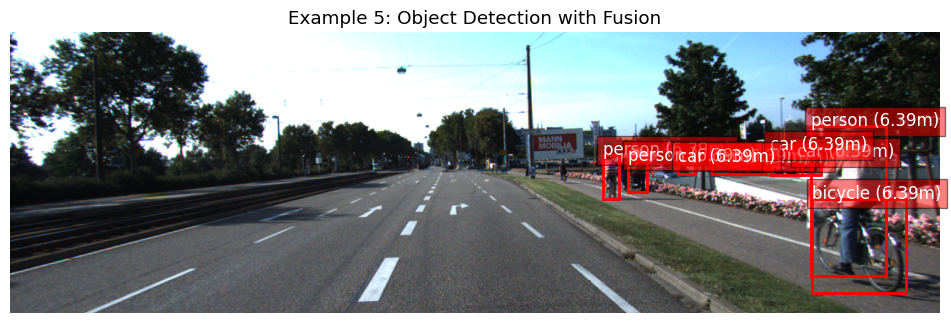

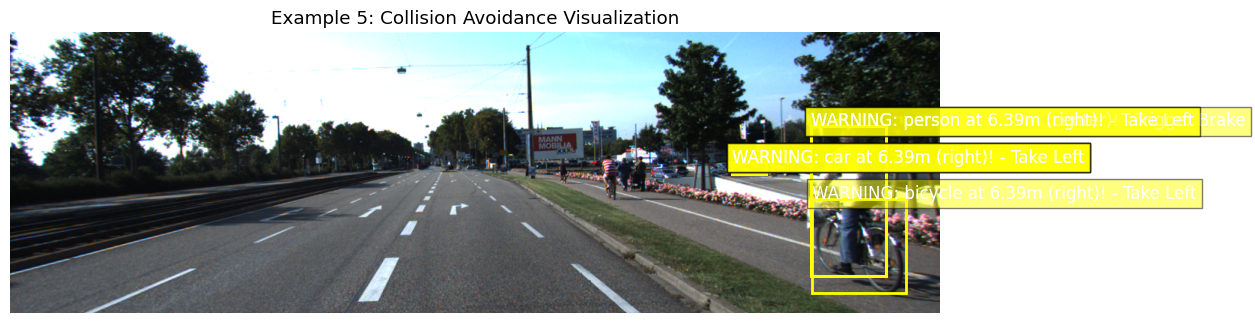

In [ ]:
# Process 5 examples to show collision avoidance variety
for i, example in enumerate(ds.take(5)):
    image = example['image'].numpy()
    lidar_points = example['objects']['location'].numpy()
    lidar_points = lidar_points[~np.isnan(lidar_points).any(axis=1)]
    lidar_fov = lidar_points[lidar_points[:, 2] < 50]

    img = Image.fromarray(image)
    results = model(img)
    detections = results.pandas().xyxy[0]
    correlated = correlate_camera_lidar(detections, lidar_fov, image.shape)

    print(f"\nExample {i+1} - Detected objects: {detections['name'].tolist()}")
    print(f"LIDAR points in FOV: {len(lidar_fov)}")

    # Assess collision risk
    collision_actions = assess_collision_risk(correlated, image.shape[1])
    for action in collision_actions:
        print(action['alert'])
        print(f"Guidance: {action['guidance']}")

    # Visualize raw image with detections
    plt.figure(figsize=(12, 8))
    plt.imshow(image)
    for obj in correlated:
        bbox = obj['bbox']
        rect = plt.Rectangle((bbox[0], bbox[1]), bbox[2] - bbox[0], bbox[3] - bbox[1],
                             linewidth=2, edgecolor='r', facecolor='none')
        plt.gca().add_patch(rect)
        plt.text(bbox[0], bbox[1], f"{obj['class']} ({obj['distance']:.2f}m)",
                 color='white', fontsize=12, bbox=dict(facecolor='red', alpha=0.5))
    plt.title(f"Example {i+1}: Object Detection with Fusion")
    plt.axis('off')
    plt.show()

    # Visualize collision avoidance if actions exist
    if collision_actions:
        plt.figure(figsize=(12, 8))
        plt.imshow(image)
        for action in collision_actions:
            bbox = next(obj['bbox'] for obj in correlated if obj['class'] == action['object'])
            rect = plt.Rectangle((bbox[0], bbox[1]), bbox[2] - bbox[0], bbox[3] - bbox[1],
                                 linewidth=2, edgecolor='yellow', facecolor='none')
            plt.gca().add_patch(rect)
            plt.text(bbox[0], bbox[1], f"{action['alert']} - {action['guidance']}",
                     color='white', fontsize=12, bbox=dict(facecolor='yellow', alpha=0.5))
        plt.title(f"Example {i+1}: Collision Avoidance Visualization")
        plt.axis('off')
        plt.show()
    else:
        print("No collision risks detected.")